In [1]:
%load_ext autoreload
%autoreload 2
import cooler
import pandas as pd

res = 12800
# res = 12800

cool_nc18 = cooler.Cooler(f'./cools/nc1-8_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_nc14 = cooler.Cooler(f'./cools/nc14_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_s10 = cooler.Cooler(f'./cools/s10-12_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')

In [2]:
%load_ext autoreload
%autoreload
import scanpy as sc
import sys

sys.path.append('./code2')

from hic_zscore_functions import make_obs_exp_intra
from aux_functions import *
from plotting_functions import *

sc.settings.set_figure_params(dpi=80, color_map='coolwarm', frameon=True)
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"axes.grid.axis" : 'both'})
plt.rcParams.update({"axes.grid" : True})

plt.rcParams.update({
    'axes.labelsize': 14,       # x and y labels' font size
    'xtick.labelsize': 8,      # x tick labels' font size
    'ytick.labelsize': 8,      # y tick labels' font size
    'axes.titlesize': 14,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'legend.fontsize': 6,      # Legend font size
})
plt.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'axes.labelsize': 8,       # x and y labels' font size
    'xtick.labelsize': 6,      # x tick labels' font size
    'ytick.labelsize': 6,      # y tick labels' font size
    'axes.titlesize': 10,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'xtick.major.pad' : 2,
    'ytick.major.pad' : 2,

})
plt.rcParams['axes.linewidth'] = .25
plt.rcParams['xtick.major.width'] = .25
plt.rcParams['ytick.major.width'] = .25
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['grid.linewidth'] = .25

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from config import load_cses, load_loop_anchors
from config import rgb_to_cluster, cluster_to_rgb

all_cses = load_cses()
all_loop_anchors = load_loop_anchors()

In [4]:
nc14_boundaries = pd.read_csv('./annotations/nc14_1_1+1_2+2_1+2_2.boundaries_and_both_with_cluster_colors.scores=plain.bed', 
                              sep = '\t', header=None)

nc14_boundaries['cluster'] = nc14_boundaries[8].apply(rgb_to_cluster.get)

In [5]:
import bbi

pref = '/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/'
bbi_bws = {
    'RNA_pol2' : bbi.open(pref + 'SRP016560.2-3hr_embryos.RNA_polymerase_II.None.False.False_bdgcmp.sorted.bw'),
    'Trl' : bbi.open(pref + 'SRP058444.2-4hr_embryos.Trl.None.False.False_bdgcmp.sorted.bw'),
    'BEAF-32' : bbi.open(pref + 'SRP007592.Kc167.BEAF-32.None.False.False_bdgcmp.sorted.bw'),
    'suHw' : bbi.open(pref + 'SRP007592.Kc167.suHw.None.False.False_bdgcmp.sorted.bw'),
    'H3K27ac' : bbi.open(pref + 'SRP044032.mitotic_cycle_14c-d.H3K27ac.None.False.False_bdgcmp.sorted.bw'),
    'H3K27me3' : bbi.open(pref + 'SRP044032.mitotic_cycle_14c-d.H3K27me3.None.False.False_bdgcmp.sorted.bw'),
    'Pc' : bbi.open(pref + 'SRP045520.4-12hr_embryos.Pc.None.False.False_bdgcmp.sorted.bw'),
    'GRO' : bbi.open('../tfs/bws/GSE41611_GRO_COMBINED.bw'),
    'RNA_pol2_1-2hr' : bbi.open(pref + 'SRP016560.1-2hr_embryos.RNA_polymerase_II.None.False.False_bdgcmp.sorted.bw'),
}

In [6]:
import bbi

h3dict = {
'H3_nc14ab' : bbi.open('/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/SRP044032.mitotic_cycle_14a-b.H3.None.False.False_bdgcmp.sorted.bw'),
'H3_nc14cd' : bbi.open('/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/SRP044032.mitotic_cycle_14c-d.H3.None.False.False_bdgcmp.sorted.bw'),
'H3_nc7-9' : bbi.open('/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/SRP044032.mitotic_cycle_7-9.H3.None.False.False_bdgcmp.sorted.bw'),
}

In [7]:
def subset_df_by_bedtool(df, bed, c=False):
    if c == False:
        has_bed = (index_to_bedtool(df.index).intersect(bed, c=True).to_dataframe(header=None).iloc[:, -1]>0).values
        return df.loc[has_bed], df.loc[~has_bed]
    else:
        has_bed = (index_to_bedtool(df.index).intersect(bed, c=True).to_dataframe(header=None).iloc[:, -1]).values
        return has_bed

In [8]:
from aux_functions import *
genes = pbt.BedTool('../for_annotations/dmel-6.39.gtf').filter(lambda x: x[2]=='gene'
                ).filter(lambda x: 'pre-mod' not in x[-1]
                ).filter(lambda x: '5Sr' not in x[-1]
                ).filter(lambda x: 'sno' not in x[-1]).saveas(
                ).saveas().to_dataframe()

genes['gene_name'] = [x.split('"')[-2] for x in genes['attributes']]
genes = genes[genes['seqname'].isin(['3L', '2L', '3R', '2R',])]
genes = genes[['seqname', 'start', 'end', 'gene_name', 'strand']]

genes.index = df_to_index(genes.iloc[:, :3])

a0, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==0]))
a1, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==1]))
a2, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==2]))
a3, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==3]))

genes['cluster0'] = genes.index.isin(a0.index)
genes['cluster1'] = genes.index.isin(a1.index)
genes['cluster2'] = genes.index.isin(a2.index)
genes['cluster3'] = genes.index.isin(a3.index)

genes.loc[genes['cluster0']>0, 'cluster'] = 0
genes.loc[genes['cluster1']>0, 'cluster'] = 1
genes.loc[genes['cluster2']>0, 'cluster'] = 2
genes.loc[genes['cluster3']>0, 'cluster'] = 3

genes_plus = genes[genes['strand'] == '+']
genes_minus = genes[genes['strand'] == '+']
genes_minus['start'] = genes_minus['end']

all_genes = pd.concat([genes_plus, genes_minus], axis=0)

/tmp/ipykernel_3191634/2052018308.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes_minus['start'] = genes_minus['end']


In [9]:
def make_values():
    values = {}
    for key in bbi_bws.keys():
        v_plus = bbi_bws[key].stackup(genes_plus['seqname'], genes_plus['start'].astype(int)-1800, genes_plus['start'].astype(int)+1800)
        v_minus = bbi_bws[key].stackup(genes_minus['seqname'], genes_minus['start'].astype(int)-1800, genes_minus['start'].astype(int)+1800)
        v_minus = v_minus.T[::-1].T
        v = np.concatenate([v_plus, v_minus], axis=0)
        values[key] = pd.DataFrame(v)
    return values

values = make_values()

In [14]:
import bbi

chrom_idx = (all_cses['chrom'] != 'Y')
nucleosome_values_cses = bbi.open('nc14_mnase_from_pairs.bw_++.bw').stackup( all_cses[chrom_idx]['chrom'], (all_cses[chrom_idx]['start'] - 1800), (all_cses[chrom_idx]['start'] + 1800 + 1),)
nucleosome_values_cses_s10_12 = bbi.open('s10-12_mnase_from_pairs.bw_++.bw').stackup( all_cses[chrom_idx]['chrom'], (all_cses[chrom_idx]['start'] - 1800), (all_cses[chrom_idx]['start'] + 1800 + 1),)

In [15]:
def make_figure_s8a_c():
        
    n = nucleosome_values_cses.shape[1]//2
    xs = np.arange(-(n-200), n+1-200)
    fig, axs = init_subplots_exact(4, 1, fgsz=(40*mm, 40*mm), dpi = 150)
    for u in np.unique(all_cses[chrom_idx]['cluster']):
        plt.sca(axs[u])
        idx = (all_cses[chrom_idx]['cluster'] == u) & (all_cses[chrom_idx]['has_loop'] == 0)
        vals = np.log2(1 + nucleosome_values_cses)[idx]
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label='Without loops', color=cluster_to_rgb[u], linestyle='dotted', zorder=3, linewidth=1.5)
        plt.fill_between(xs, v - v_sem, v + v_sem, color='lightgray', alpha=0.5, zorder=2)
        
        idx = (all_cses[chrom_idx]['cluster'] == u) & (all_cses[chrom_idx]['has_loop'] == 1)
        vals = np.log2(1 + nucleosome_values_cses)[idx]
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label='With loops', color=cluster_to_rgb[u], zorder=3, linewidth=1)
        plt.fill_between(xs, v - v_sem, v + v_sem, color='lightgray', alpha=0.5, zorder=2)
        
        plt.title(f'Cluster {u}')
        plt.legend(bbox_to_anchor=(0, 0), title=f'Cluster {u}', title_fontsize=6, loc='lower left', frameon=False, handlelength=2)
    
        plt.ylim([.2, .8])
    for ax in axs:
        plt.sca(ax)
        ax.set_xticks([-n, 0, n])
        ax.set_xticklabels(['-2kb', 'CSE', '+2kb'])
    
    plt.sca(axs[0])
    plt.ylabel("Nucleosome coverage")

    
    n = nucleosome_values_cses.shape[1]//2
    fig, axs = init_subplots_exact(4, 1, fgsz=(40*mm, 40*mm), dpi = 150)
    for u in np.unique(all_cses[chrom_idx]['cluster']):
        plt.sca(axs[u])
        idx = (all_cses[chrom_idx]['cluster'] == u) & (all_cses[chrom_idx]['has_loop'] == 0)
        vals = np.log2(1 + h3dict['H3_nc14ab'].stackup(
        all_cses[chrom_idx][idx]['chrom'],
        all_cses[chrom_idx][idx]['start'] - 2_000,
        all_cses[chrom_idx][idx]['end'] + 2_000,    
        ))
        xs = np.linspace(-2200, 2200, 4400)
        
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label='Without loops', color=cluster_to_rgb[u], linestyle='dotted', linewidth=1.5)
        plt.fill_between(xs, v - v_sem, v + v_sem, color='lightgray', alpha=0.5)
        
        idx = (all_cses[chrom_idx]['cluster'] == u) & (all_cses[chrom_idx]['has_loop'] == 1)
        vals = np.log2(1 + h3dict['H3_nc14ab'].stackup(
        all_cses[chrom_idx][idx]['chrom'],
        all_cses[chrom_idx][idx]['start'] - 2_000,
        all_cses[chrom_idx][idx]['end'] + 2_000,    
        ))
        # vals = np.log2(1 + nucleosome_values_cses_nc1_8)[idx]
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label='With loops', color=cluster_to_rgb[u], linewidth=1)
        plt.fill_between(xs, v - v_sem, v + v_sem, color='lightgray', alpha=0.5)
        plt.title(f'Cluster {u}')
        plt.legend(bbox_to_anchor=(0, 0), title=f'Cluster {u}', title_fontsize=6, loc='lower left', frameon=False, handlelength=2)
        plt.ylim([0, .9])
    
        
    for ax in axs:
        plt.sca(ax)
        ax.set_xticks([-n, 0, n])
        ax.set_xticklabels(['-2kb', 'CSE', '+2kb'])
    
    plt.sca(axs[0])
    plt.ylabel("H3 density")

    
    
    n = nucleosome_values_cses_s10_12.shape[1]//2
    xs = np.arange(-(n-200), n+1-200)
    fig, axs = init_subplots_exact(4, 1, fgsz=(40*mm, 40*mm), dpi = 150)
    for u in np.unique(all_cses[chrom_idx]['cluster']):
        plt.sca(axs[u])
        idx = (all_cses[chrom_idx]['cluster'] == u) & (all_cses[chrom_idx]['has_loop'] == 0)
        vals = np.log2(1 + nucleosome_values_cses_s10_12)[idx]
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label='Without loops', color=cluster_to_rgb[u], linestyle='dotted', zorder=3, linewidth=1.5)
        # plt.fill_between(xs, v - v_sem, v + v_sem, color=cluster_to_rgb[u], alpha=0.3, zorder=2)
        plt.fill_between(xs, v - v_sem, v + v_sem, color='lightgray', alpha=0.5, zorder=2)
        
        idx = (all_cses[chrom_idx]['cluster'] == u) & (all_cses[chrom_idx]['has_loop'] == 1)
        vals = np.log2(1 + nucleosome_values_cses_s10_12)[idx]
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label='With loops', color=cluster_to_rgb[u], zorder=3, linewidth=1)
        plt.fill_between(xs, v - v_sem, v + v_sem, color='lightgray', alpha=0.5, zorder=2)
        
        
        plt.title(f'Cluster {u}')
        plt.legend(bbox_to_anchor=(0, 0), title=f'Cluster {u}', title_fontsize=6, loc='lower left', frameon=False, handlelength=2)
    
        plt.ylim([.1, .9])
    for ax in axs:
        plt.sca(ax)
        ax.set_xticks([-n, 0, n])
        ax.set_xticklabels(['-2kb', 'CSE', '+2kb'])
    
    plt.sca(axs[0])
    plt.ylabel("Nucleosome coverage")

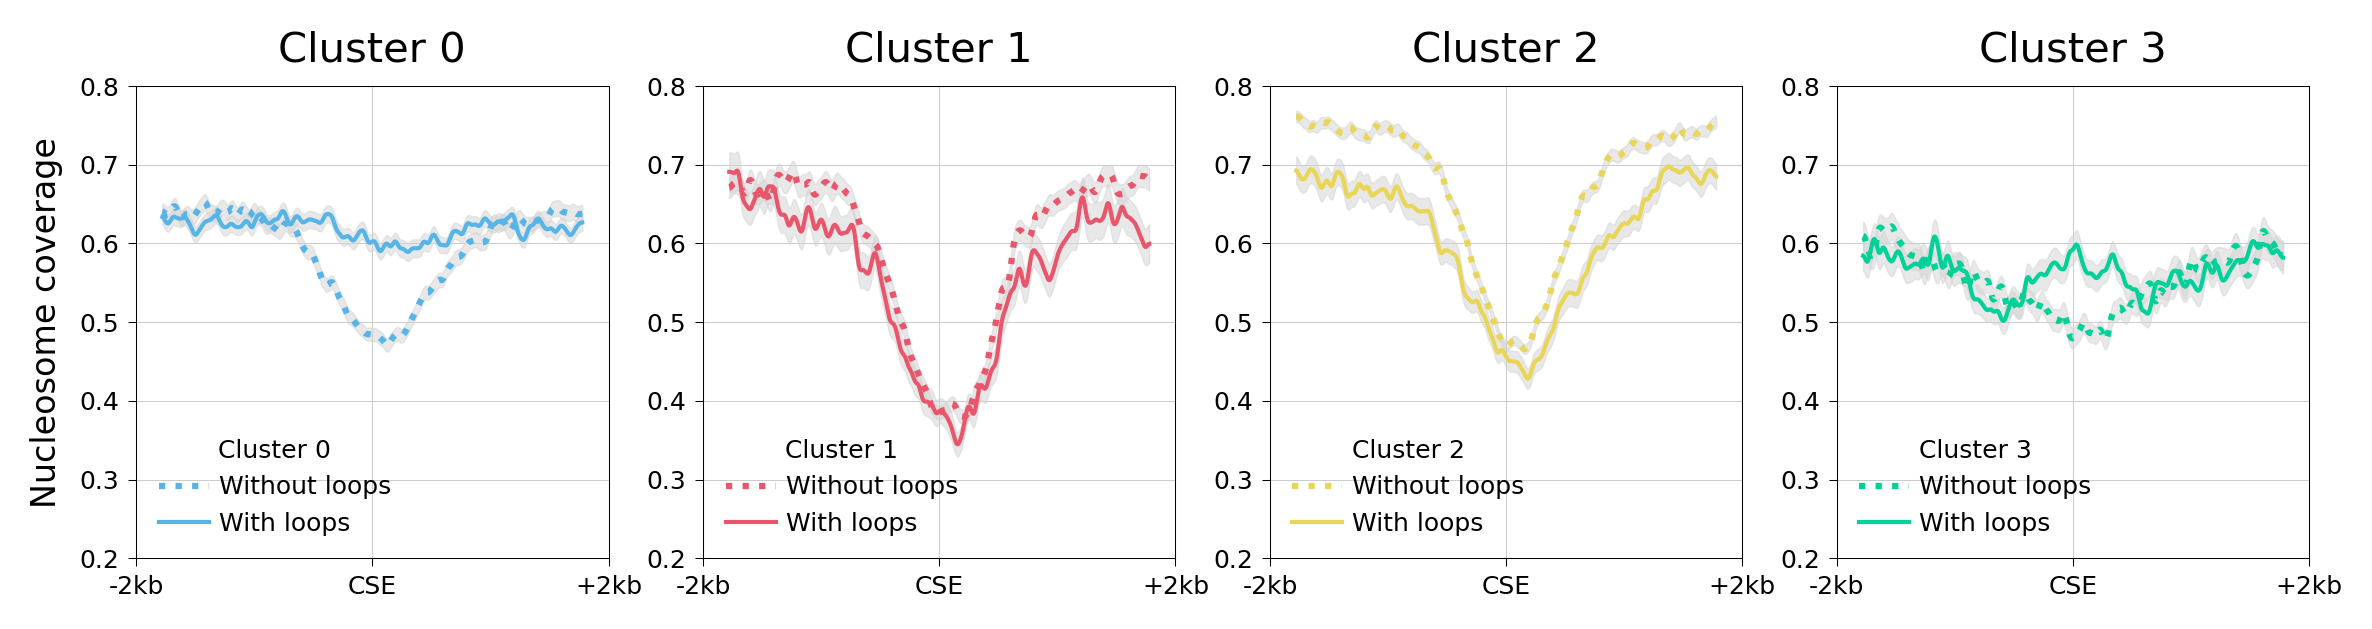

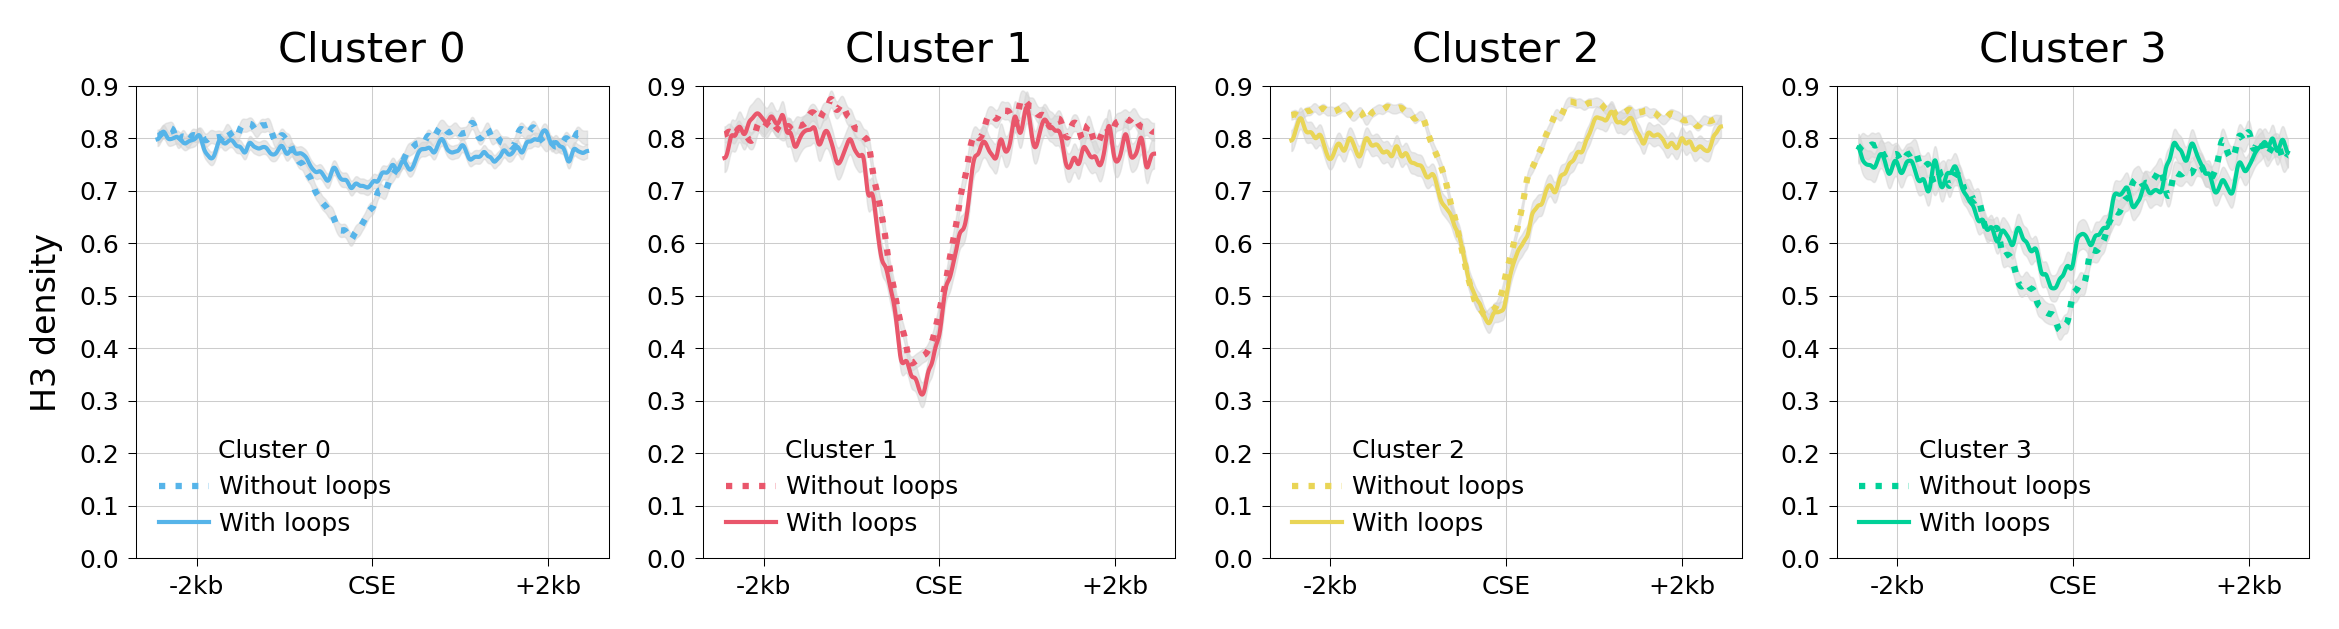

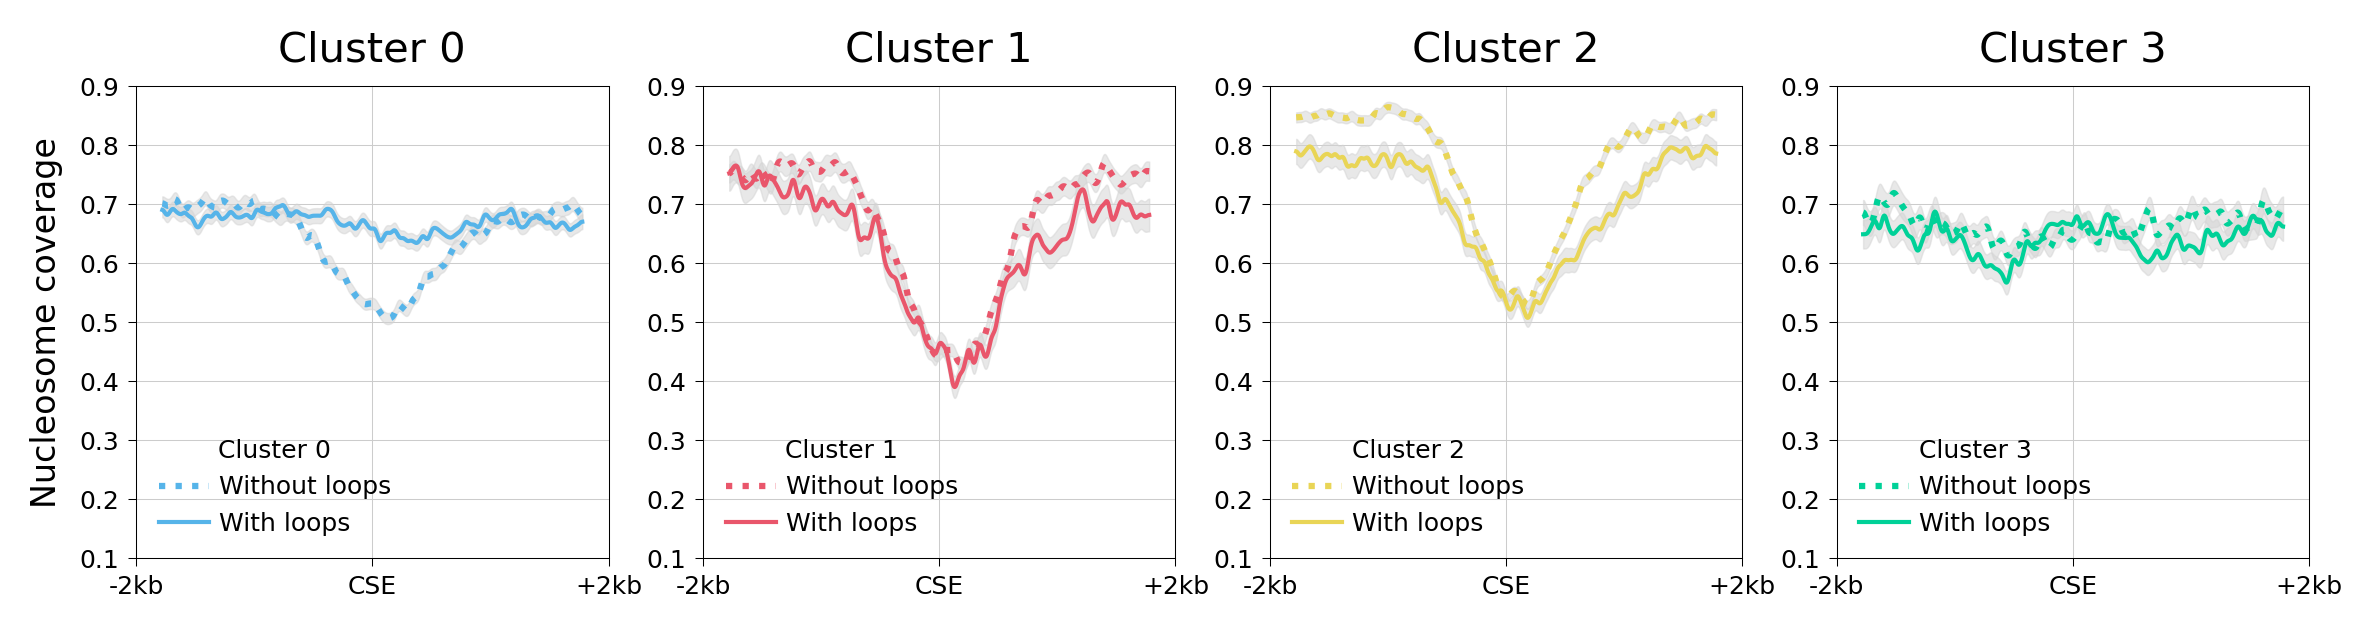

In [16]:
make_figure_s8a_c()

In [17]:
from matplotlib.colors import LinearSegmentedColormap

# Define your four RGB colors (values should be between 0 and 1)
colors = list(cluster_to_rgb.values())

# Create a colormap from the four colors
cluster_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

def get_nucleosome_values(bw, genes_plus, genes_minus):
    nucleosome_values_plus = bw.stackup( genes_plus['seqname'], (genes_plus['start'] - 1800), (genes_plus['start'] + 1800),)
    nucleosome_values_minus = bw.stackup( genes_minus['seqname'], (genes_minus['start'] - 1800), (genes_minus['start'] + 1800), ).T[::-1].T
    return np.concatenate([nucleosome_values_plus, nucleosome_values_minus[::-1]], axis=0)
def relabel_clusters(cluster, order):
    seen = set()
    newcluster = cluster.copy()
    for c, i in enumerate(cluster[order]):
        if i in seen:
            continue
        else:
            seen.add(i)
            newcluster[cluster==i] = len(seen)-1
    return newcluster

def get_o_clusts(tf_vals, n_clusters=4):
    if len(tf_vals.shape)==1:
        _, clust, _ = make_order_and_cluster_custom(tf_vals[:, None], n_clusters=n_clusters, method='ward', metric='euclidean')
        o = np.argsort(-tf_vals)
        clust = relabel_clusters(clust, o)
    else:
        o, clust, _ = make_order_and_cluster_custom(tf_vals, n_clusters=n_clusters, method='ward', metric='euclidean')
    return o, clust    

def make_mnase_plot(mat_dict, tf_vals, genes, n_clusters=4):
    o, clust = get_o_clusts(tf_vals, n_clusters=4)
    clust[tf_vals > np.nanquantile(tf_vals, .95)] = 0
    clust[(tf_vals < np.nanquantile(tf_vals, .95)) & (tf_vals > np.nanquantile(tf_vals, .9))] = 1
    clust[(tf_vals < np.nanquantile(tf_vals, .9)) & (tf_vals > np.nanquantile(tf_vals, .6))] = 2
    clust[(tf_vals < np.nanquantile(tf_vals, .6))] = 3
    
    n_plots = (len(mat_dict) + 1) * 2
    fig, axs = init_subplots_exact(n_plots, 2, fgsz=(4*.5, 4*.5), y_ratios = [.2, .9], x_ratios=[.1] + [.9]*len(mat_dict), 
                                   dpi = 80, xspace=1.2, yspace=1.05)
    
    
    newax = add_vector_to_L_axis(genes['cluster'].fillna(np.nan).values[o], axs[n_plots//2], cmap=cluster_cmap, aspect='auto',
                        x=-2, vmin = 0, vmax=3)
    newax.set_xticks([])
    newax.set_yticks([])

    axs[0].remove()

    for c, (key, mat) in enumerate(mat_dict.items()):
        c = c + 1
        mat = mat[:, 800:-800]
        dist = mat.shape[1]//2
        n = mat.shape[0]
        if c == 1:
            plt.sca(axs[n_plots//2])
            axs[n_plots//2].matshow(clust[o][:, None], aspect='auto', cmap='tab20', vmin=0, vmax=20, zorder=3, extent=[-dist, dist, n, 0],
                                   rasterized=True)
            axs[n_plots//2].set_xticks([])
            axs[n_plots//2].set_yticks([0, n])    

        print(mat.shape)
        if key == 'MNase Coverage':
            m = scipy.ndimage.gaussian_filter(np.log2(1+mat).astype(float)[o], sigma=8)
            vmax = 10
        else:
            m = scipy.ndimage.gaussian_filter(np.log2(1+mat).astype(float)[o], sigma=4)
            vmax=None
    
        plt.sca(axs[c+n_plots//2])
        axs[c+n_plots//2].matshow(m, aspect='auto', cmap='gist_heat_r', zorder=3, extent=[-dist, dist, n, 0],
                                 vmax=vmaxdict[key][1],
                                 vmin=vmaxdict[key][0])
        for u in range(6):
            idx = (clust == u)
            if key == 'MNase Coverage':
                v = scipy.ndimage.gaussian_filter1d(np.nanmean(np.log2(1+mat[idx]), axis=0), sigma = 8)
            else:
                v = np.nanmean(np.log2(1+mat[idx]), axis=0)
    
            axs[c].plot(v, color=sns.color_palette('tab20')[u], linewidth=2)
            axs[c].tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
        axs[c+n_plots//2].set_yticks([])
        axs[c].set_title(key)
    
    for ax in axs[-n_plots//2+1:]:
        ax.set_xticks([-dist, 0, dist])
        ax.set_xticklabels([f'{-int(dist//1e3)}kb', f'TSS', f'{int(dist//1e3)}kb'])
        ax.tick_params(bottom=True, labelbottom=True, top=False, labeltop=False)
        
    for ax in axs:
        ax.grid(True)    
    return clust, o, fig

def add_vector_to_L_axis(vector, ax, ignore_set=[], bins=1000, x=-1, 
                     roundby = -5, label_for_title='', ylimdict = {}, cmap=None, **kwargs):
    newaxs = []
    newax1 = ax.inset_axes(transform=ax.transAxes, bounds = (x, 0, 1, 1))
    newax1.matshow(vector[:, None], cmap=cmap, **kwargs)
    return newax1

In [18]:
nucleosome_values_nc1_8_genes = get_nucleosome_values(bbi.open('nc1-8_mnase_from_pairs.bw_++.bw'), genes_plus, genes_minus)

mat_dict_nc18 = {
    'MNase Coverage' : nucleosome_values_nc1_8_genes,
    'Trl' : values['Trl'].values,
    'RNA Pol2' : values['RNA_pol2'].values,
    'BEAF-32' : values['BEAF-32'].values,
    'suHw' : values['suHw'].values,
    'H3K27ac' : values['H3K27ac'].values,
    'H3K27me3' : values['H3K27me3'].values,
}

4
(14658, 2000)


/tmp/ipykernel_3191634/3648282245.py:79: RuntimeWarning: Mean of empty slice
  v = scipy.ndimage.gaussian_filter1d(np.nanmean(np.log2(1+mat[idx]), axis=0), sigma = 8)


(14658, 2000)


/tmp/ipykernel_3191634/3648282245.py:81: RuntimeWarning: Mean of empty slice
  v = np.nanmean(np.log2(1+mat[idx]), axis=0)


(14658, 2000)
(14658, 2000)
(14658, 2000)
(14658, 2000)
(14658, 2000)


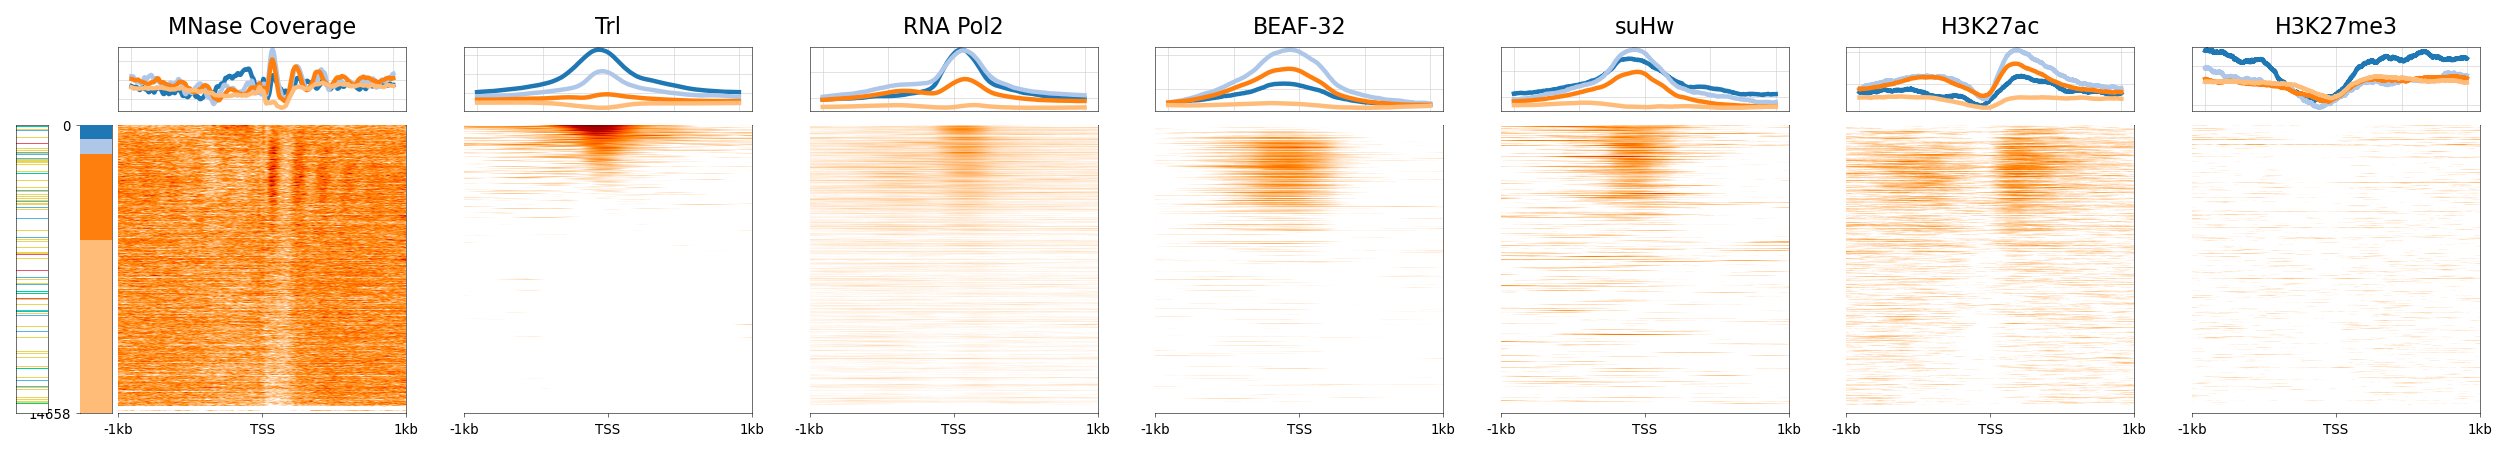

In [19]:
vmaxdict = {
    'MNase Coverage' : [0.7, 2],
    'Trl' : [.75, 6],
    'RNA Pol2' : [.75, 8],
    'BEAF-32' : [.75, 8],
    'suHw' : [.75, 3],
    'H3K27ac' : [.75, 5],
    'H3K27me3' : [.75, 5],
}

trl_vals = np.log2(1+np.nanmean(values['Trl'].iloc[:, 1500:2000], axis=1))
clust_pol2, o, fig = make_mnase_plot(mat_dict_nc18, trl_vals, all_genes)

In [20]:
def mod_index(df, k=1):
    df.index = ["_".join([make_int(x.split("_"))[0], str(make_int(x.split("_"))[1]+k), str(make_int(x.split("_"))[2])])
                for x in df.index ]
    return df


In [21]:
import os
import h5py

def make_figure_s8f():
    # Load in individual files made.
    h5 = h5py.File("/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/4DN_data/testaroo/overlapping.base_resolution=100.resolution=400.window_size=16.d=3.boundaries.cutoff=1.00e+00.blacklist=all_stages_final.{}.kind=signal.h5".format('SRP044032.mitotic_cycle_14c-d.H3K9ac.None.False.False'), "r")
    imputed_d = h5["labels_norm"][:]
    h5.close()
    
    d = "/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/4DN_data/chip_seq_at_boundaries"
    
    cur_file = "{}.base_resolution=100.resolution={}.window_size={}.d=3.boundaries.cutoff={}.blacklist={}.combined.df_subset={}.kind={}.h5".format(
        "overlapping", "400", "16", "1.00e+00", "all_stages_final", "all", "signal")
    cur_file = os.path.join(d, cur_file)
    h5 = h5py.File(cur_file, "r")
    distinct_features = h5.attrs["distinct_features"]
    cur_x = h5["labels_norm"][()]
    h5.close()
    
    pref = '/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/4DN_data'
    all_cses_here = pbt.BedTool(pref + '/merged_boundaries/overlapping.base_resolution=100.resolution=400.window_size=16.d=3.boundaries.cutoff=1.00e+00.blacklist=all_stages_final.bed.gz').to_dataframe()
    
    import cooler
    s = all_cses_here.iloc[:, :3].copy()
    s['start'] -= 200
    s['end'] += 200
    all_chip_data = pd.DataFrame(cur_x, columns = distinct_features, index = [x for x in df_to_index(s)])
    mod_index(all_chip_data, -1);
    
    same = all_chip_data.index.intersection(all_cses.index)
    
    all_fcs = pd.DataFrame()
    all_pvals = pd.DataFrame()
    
    for u in np.unique(all_cses['cluster']):
        idx1 = (all_cses.loc[same, 'cluster'] == u) & (all_cses.loc[same, 'has_loop'] > 0)
        idx2 = (all_cses.loc[same, 'cluster'] == u) & (all_cses.loc[same, 'has_loop'] == 0)
        all_fcs[u] = (all_chip_data.loc[same][idx1].mean() / all_chip_data.loc[same][idx2].mean())
        all_pvals[u] = scipy.stats.ranksums(all_chip_data.loc[same][idx1],  all_chip_data.loc[same][idx2])[1]
    all_fcs = np.log2(all_fcs)
    all_fcs.index = [x.split(".")[2] for x in all_fcs.index]
    
    all_pvals.index = all_fcs.index
    
    idx = ((all_fcs.abs() > 1) & (all_pvals < 1e-3)).any(axis=1)
    data = all_fcs[idx]
    data = data[~data.index.duplicated()]
    data.columns.name = 'Cluster'
    g = sns.clustermap(data, cmap='coolwarm', col_cluster=False, vmin = -3, vmax=3, zorder=3, figsize=(2, 3),
                      cbar_pos=(1.1, .5, .05, .2))
    
    g.ax_heatmap.collections[0].colorbar.set_label('ChIP LFC', rotation=90, labelpad=-40)
    # Add labels above and below the colorbar
    colorbar = g.ax_heatmap.collections[0].colorbar
    colorbar.ax.text(0.5, 1.05, 'Loop', ha='center', va='bottom', transform=colorbar.ax.transAxes,fontsize=8)
    colorbar.ax.text(0.5, -0.1, 'Boundary', ha='center', va='top', transform=colorbar.ax.transAxes,fontsize=8)
    
    plt.show()
    g.fig.savefig('./new_figures/r8/loop_boundary_chip.pdf', bbox_inches='tight')

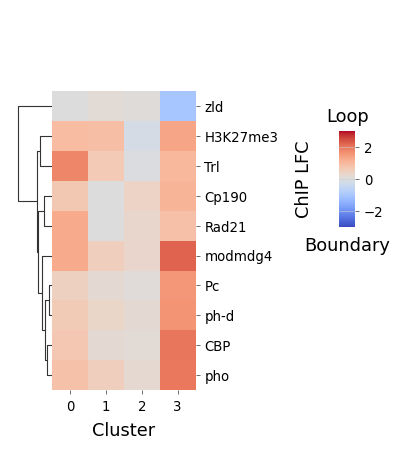

In [22]:
make_figure_s8f()

In [23]:
import numpy as np
import scipy.ndimage
import seaborn as sns
import matplotlib.pyplot as plt
import bbi
import numpy as np 

def make_figure_S8_G():
    chrom_list = ["3R", "3L", "2R", '2L', '4', 'X']  # Modify as needed
    zld_peaks = pbt.BedTool('/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/SRP052975.2-3hr_embryos.zld.None.False.False_peaks.narrowPeak'
               ).to_dataframe()
    zld_peaks = zld_peaks[zld_peaks['chrom'].isin(chrom_list)]
    zld_peaks['midpt'] = (zld_peaks['start'] + zld_peaks['end'])//2
    zld_peaks = zld_peaks.drop(zld_peaks.index[9056])    
    
    pref = '/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/'
    zld_bw1 = bbi.open('/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/SRP052975.2-3hr_embryos.zld.None.False.False_bdgcmp.sorted.bw')
    zld_vals_at_peaks = zld_bw1.stackup(zld_peaks['chrom'], zld_peaks['midpt'] - 1800,  zld_peaks['midpt'] + 1800)
    
    
    
    nucleosome_vals_at_peaks = bbi.open('nc14_mnase_from_pairs.bw_++.bw').stackup( zld_peaks['chrom'], (zld_peaks['midpt'] - 1800), (zld_peaks['midpt'] + 1800))
    nucleosome_vals_at_peaks_nc1_8 = bbi.open('nc1-8_mnase_from_pairs.bw_++.bw').stackup( zld_peaks['chrom'], (zld_peaks['midpt'] - 1800), (zld_peaks['midpt'] + 1800))
    nucleosome_vals_at_peaks_s10_12 = bbi.open('s10-12_mnase_from_pairs.bw_++.bw').stackup( zld_peaks['chrom'], (zld_peaks['midpt'] - 1800), (zld_peaks['midpt'] + 1800))
    
    mid = zld_vals_at_peaks.shape[1]//2
    
    n_quantiles = 5
    bins = pd.qcut(np.nanmean(zld_vals_at_peaks[:, mid-200:mid+200], axis=1), n_quantiles, labels=False)
    
    colors = sns.color_palette('Reds', n_colors=n_quantiles)
    xs = np.linspace(-1800, 1800, 3600)
    fig, axs = init_subplots_exact(1, 1, fgsz=(3, .75), dpi = 150)
    for i in range(n_quantiles):
        idx = bins == i
        v = scipy.ndimage.gaussian_filter1d(np.nanmean(zld_vals_at_peaks[idx], axis=0), sigma=10)
        plt.plot(xs, v, c = colors[i],linewidth = 1,
                label=f'{int(i/5*100)}-{int((i+1)/5*100)}% strongest binding')
        plt.xticks([-1500, 0, 1500])
        axs.set_xticklabels(['-1.5kb', 'Zld Peak', '+1.5kb'])
        plt.ylabel("Zld ChIP")
        plt.xlabel("Genomic Distance")
        plt.legend(bbox_to_anchor=(1,1), title="Zld peaks")
        axs.spines['top'].set_visible(False)
        axs.spines['right'].set_visible(False)
    
    colors = sns.color_palette('Reds', n_colors=n_quantiles)
    xs = np.linspace(-1800, 1800, 3600)
    
    datasets = [
        ('nc14', nucleosome_vals_at_peaks, (0.65, 1.1)),
        ('s10-12', nucleosome_vals_at_peaks_s10_12, (0.8, 1.2)),
        ('nc1-8', nucleosome_vals_at_peaks_nc1_8, (1.5, 2.0)),
    ]
    
    def plot_nucleosome_profile(data, ylim):
        fig, axs = init_subplots_exact(1, 1, fgsz=(3, .75), dpi=150)
    
        for i in range(n_quantiles):
            idx = bins == i
            mean_vals = np.nanmean(data[idx], axis=0)
            smoothed_mean = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=40)
            sem_vals = scipy.ndimage.gaussian_filter1d(data[idx], sigma=40, axis=1).std(axis=0, ddof=1) / np.sqrt(idx.sum())
    
            plt.plot(xs, smoothed_mean, c=colors[i], linewidth=1,
                     label=f'{int(i/5*100)}-{int((i+1)/5*100)}% strongest binding')
            plt.fill_between(xs, smoothed_mean - sem_vals, smoothed_mean + sem_vals, color=colors[i], alpha=0.3)
    
        plt.ylabel("MNase Coverage")
        plt.xticks([-1500, 0, 1500])
        axs.set_xticklabels(['-1.5kb', 'Zld Peak', '+1.5kb'])
        plt.xlabel("Genomic Distance")
        plt.legend(bbox_to_anchor=(1, 1), title="Zld peaks")
        axs.spines['top'].set_visible(False)
        axs.spines['right'].set_visible(False)
        plt.ylim(ylim)
    
    for title, data, ylim in datasets:
        plot_nucleosome_profile(data, ylim)
        plt.title(title)

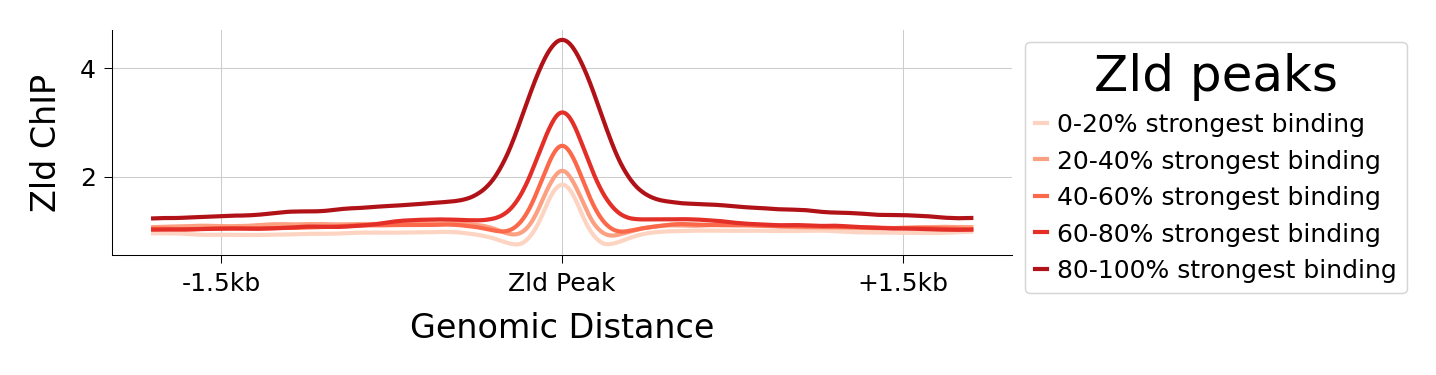

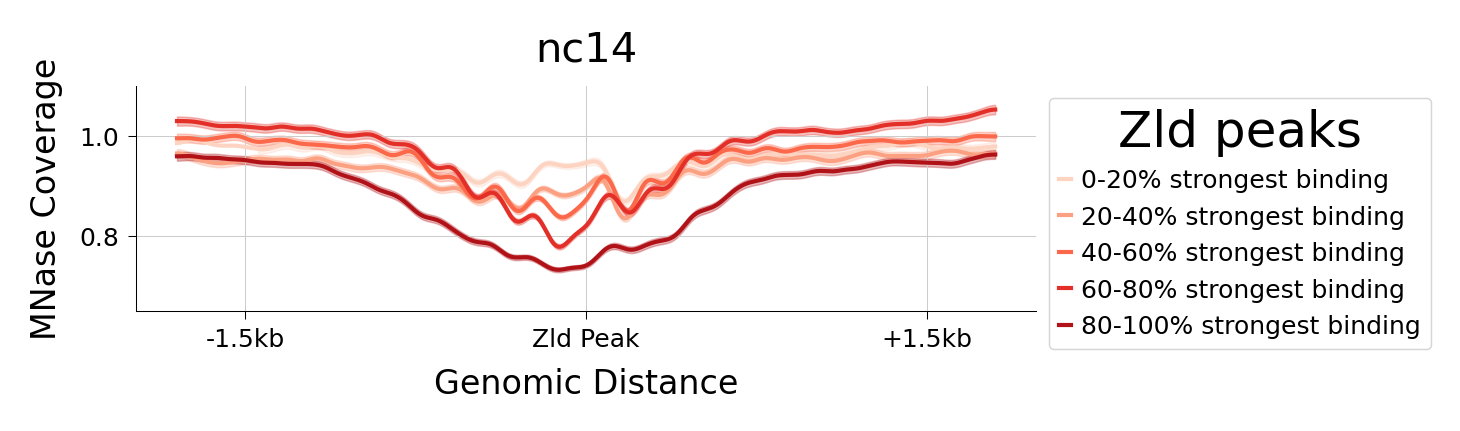

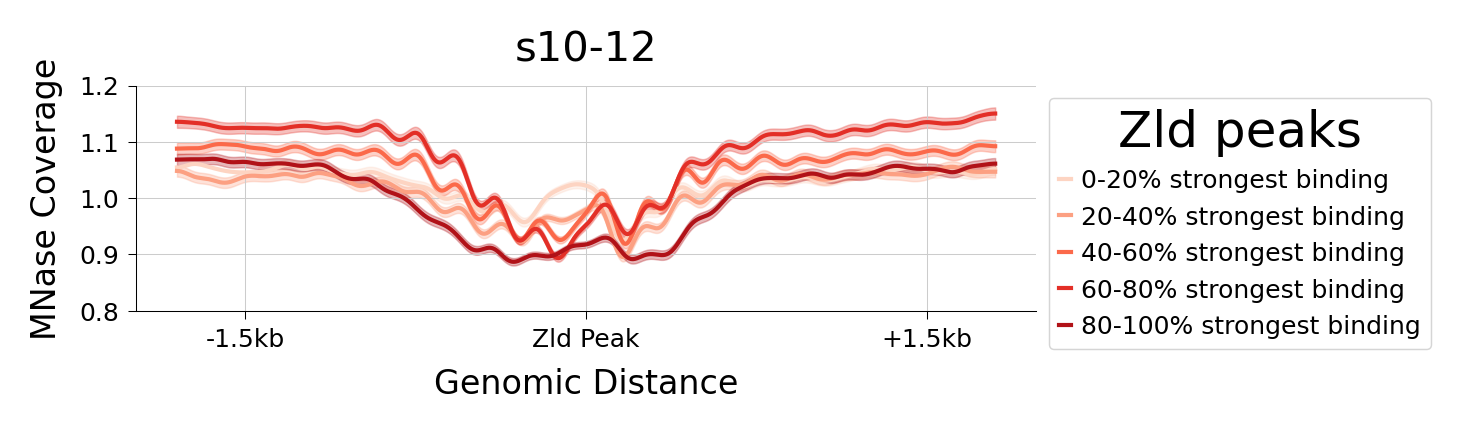

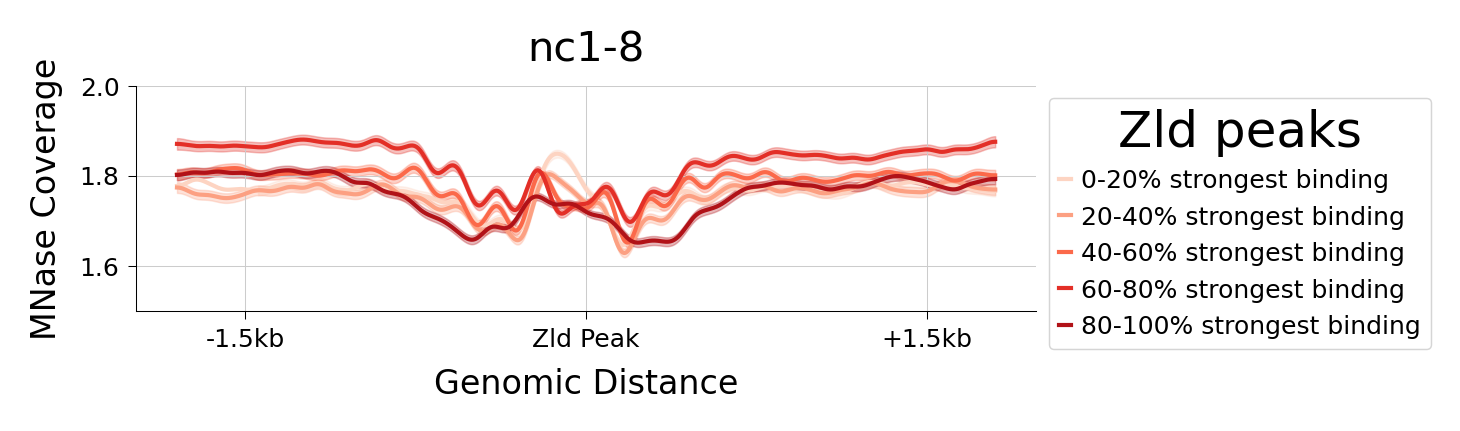

In [24]:
make_figure_S8_G()

In [25]:
def make_figure_s8h():    
    trl_vals = np.log2(1+np.nanmean(values['Trl'].iloc[:, 1500:2000], axis=1))
    
    o, clust_trl = get_o_clusts(trl_vals, n_clusters=4)
    clust_trl[trl_vals > np.nanquantile(trl_vals, .95)] = 0
    clust_trl[(trl_vals < np.nanquantile(trl_vals, .95)) & (trl_vals > np.nanquantile(trl_vals, .9))] = 1
    clust_trl[(trl_vals < np.nanquantile(trl_vals, .9)) & (trl_vals > np.nanquantile(trl_vals, .6))] = 2
    clust_trl[(trl_vals < np.nanquantile(trl_vals, .6))] = 3
    
    colsoi = ['mE_mRNA_em0-2hr', 'mE_mRNA_em2-4hr', 'mE_mRNA_em4-6hr', 'mE_mRNA_em6-8hr', 'mE_mRNA_em8-10hr', 'mE_mRNA_em10-12hr', 'mE_mRNA_em12-14hr', 'mE_mRNA_em14-16hr', 'mE_mRNA_em16-18hr', 'mE_mRNA_em18-20hr', 'mE_mRNA_em20-22hr', 'mE_mRNA_em22-24hr',]
    rna_seq_data = pd.read_csv('../annotations/gene_rpkm_matrix_fb_2021_03.tsv', sep='\t',
               skiprows=4,
               skipfooter=1)
    rna_seq_data = rna_seq_data[rna_seq_data['gene_type'] == 'protein_coding_gene']
    rna_seq_data = rna_seq_data.set_index('gene_symbol').drop(['#gene_primary_id', 'gene_fullname', 'gene_type'], axis=1)
    rna_seq_data.columns = [x.split("_(")[0] for x in rna_seq_data.columns]
    rna_seq_data = rna_seq_data[colsoi]
    rna_seq_data = rna_seq_data.dropna() 
    rna_seq_data.index = rna_seq_data.index.astype(str)    

    all_genes['trl_cluster'] = clust_trl
    fig, axs = init_subplots_exact(5, 2, dpi = 150, yspace = 1.4, fgsz=(1.5, 1.5) )
    for u in [-1, 0, 1, 2, 3]:
        plt.sca(axs[u+1])
        subset = all_genes[all_genes['trl_cluster']==0]
        subset = subset[subset['gene_name'].isin(rna_seq_data.index)]
        idx = subset['gene_name'][subset['cluster'].fillna(-1) == u]
        xs = [x.split("em")[1] for x in np.log2(1+rna_seq_data.loc[idx]).mean(axis=0).index]
        
        
        ys = np.log2(1+rna_seq_data.loc[idx])
        sem = ys.std(axis=0, ddof=1) / np.sqrt(ys.shape[0])
        v = ys.mean(axis=0)
        plt.plot(xs, v, label = f'Top 5% GAF\nn={len(idx)}', linewidth=2,
                 color = cluster_to_rgb.get(u, 'black'),
                )
        plt.fill_between(xs, v - sem, v + sem, color='lightgray', alpha=0.5)
    
        baseline_idx = all_genes['gene_name'][all_genes['cluster'].fillna(-1)==u]
        baseline_idx = baseline_idx[baseline_idx.isin(rna_seq_data.index)]
    
        
        ys = np.log2(1+rna_seq_data.loc[baseline_idx])
        sem = ys.std(axis=0, ddof=1) / np.sqrt(ys.shape[0])
        v = ys.mean(axis=0)
        plt.plot(xs, v, label = f'Other genes in cluster \nn={len(baseline_idx)}', linewidth=2,
                 color = cluster_to_rgb.get(u, 'black'), linestyle='--', 
                )
        plt.fill_between(xs, v - sem, v + sem, color='lightgray', alpha=0.5)
        
        plt.legend(handlelength=3, bbox_to_anchor=(0, 0), loc = 'lower left')
        if u == -1:
            plt.title(f"TSSs not near CSEs")
        else:
            plt.title(f"TSSs near Cluster {u} CSEs")
    
        plt.ylabel("Log RNA-seq")
        plt.xticks(rotation=40);
        plt.ylim(0, 5)


4


/tmp/ipykernel_3191634/3365727857.py:11: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  rna_seq_data = pd.read_csv('../annotations/gene_rpkm_matrix_fb_2021_03.tsv', sep='\t',


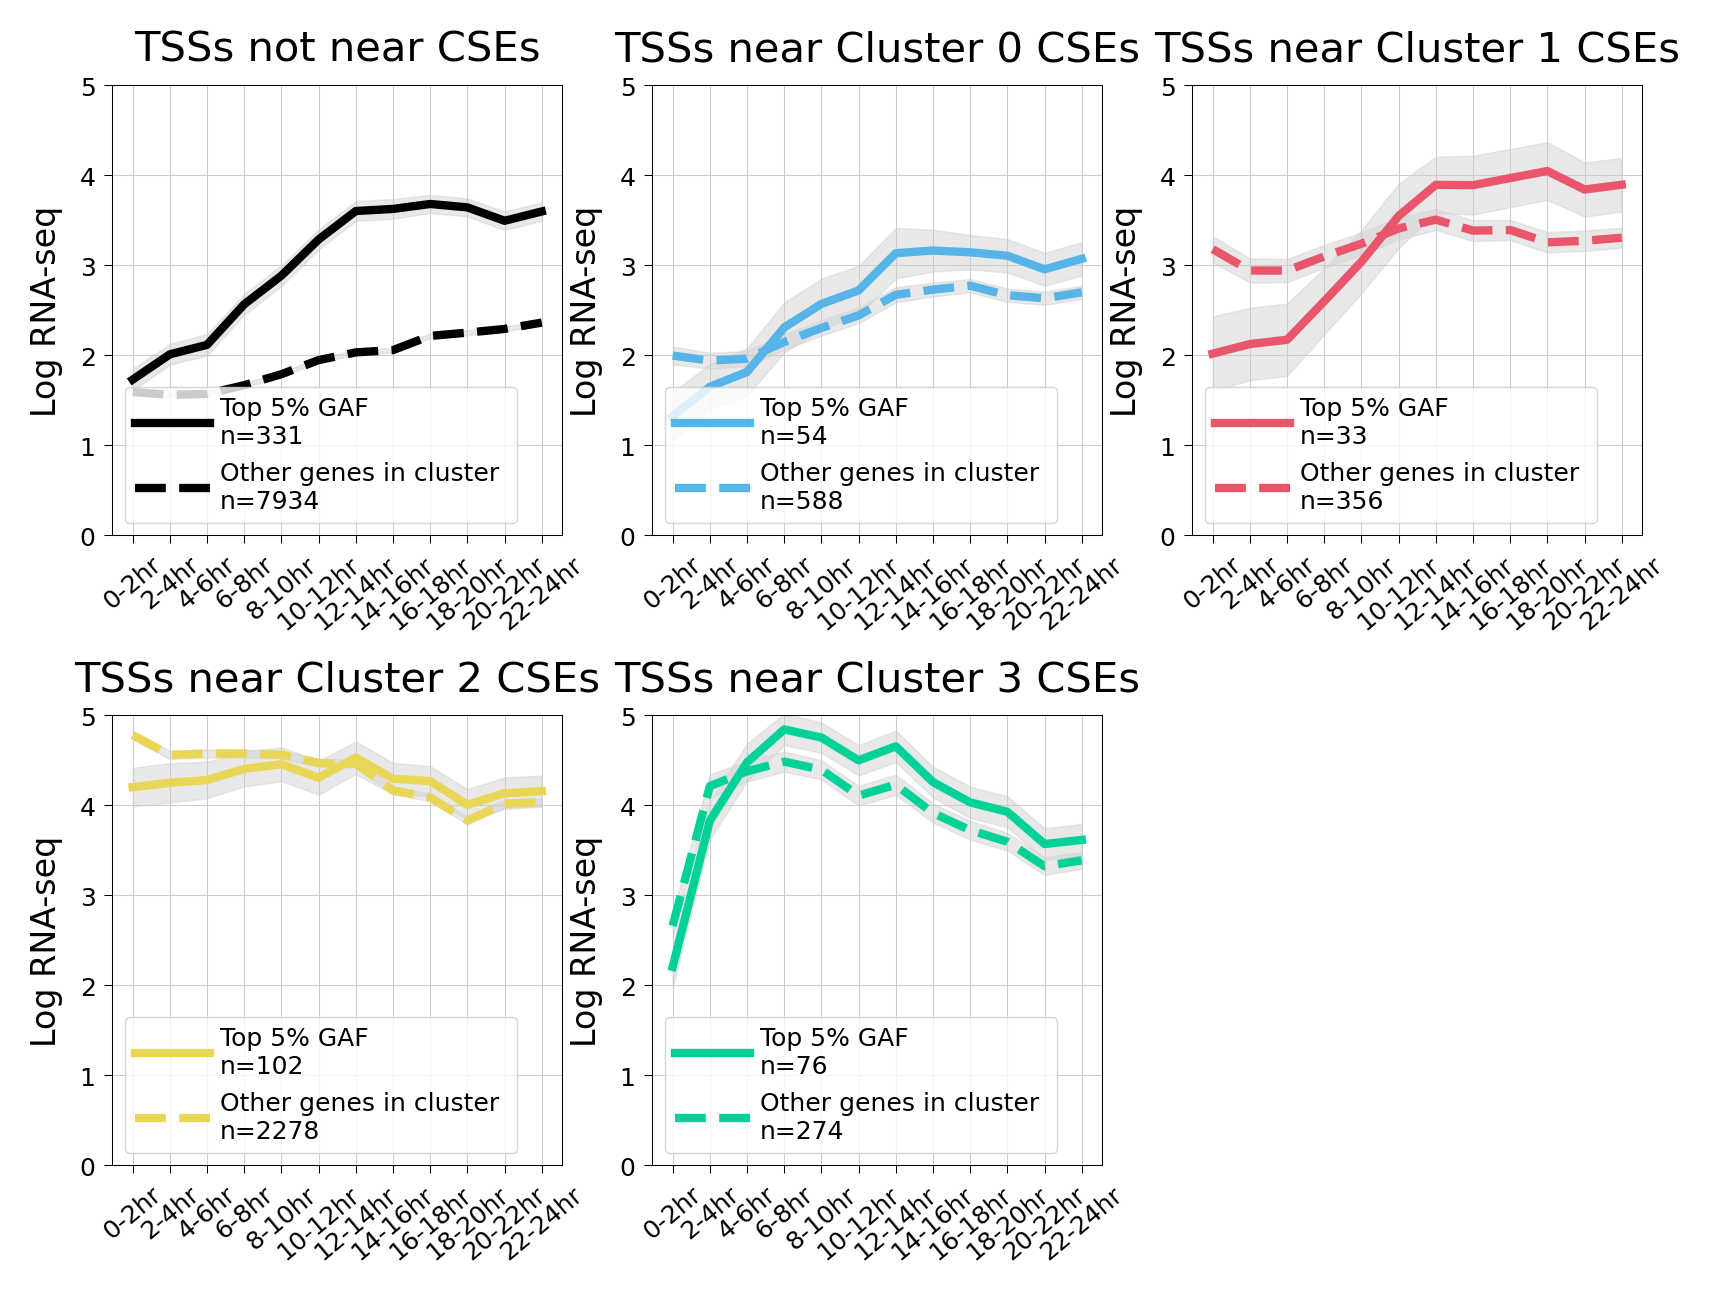

In [26]:
make_figure_s8h()